# VANET-Parking Post-Processor — Three-Source Analysis
Statistical analysis and visualization of simulation logs from the vehicular network.

---

### Overview
This notebook processes logs from three sources:
- **Core (Rust)**: vanet-parking assignment algorithm logs (NDJSON)
- **Bridge**: Ground truth parking state bridge logs (plain text)
- **Van3twin**: SUMO mobility simulation logs (plain text)

### Output
- CSV reports in `./output/`
- Charts in `./output/figures/`

---

## Metrics Overview

### A. Core Rust — Assignment Algorithm
| ID | Metric | Description |
| :--- | :--- | :--- |
| **A1** | **Timer Backoff Distribution** | Distribution of `timer_ms` computed by vehicles when starting the assignment procedure. |
| **A2** | **Assignment Funnel** | Conversion funnel: timers started → attempts → slots won. |
| **A3** | **Assignment Latency** | Time between timer start and successful slot assignment (`elapsed_ms`). |
| **A4** | **Slot Contention** | Number of vehicles competing for the same slot. |
| **A5** | **Jain Fairness Index** | Fairness of slot distribution across vehicles. |
| **A6** | **Gossip Propagation Latency** | Time for an occupied slot notification to propagate via gossip. |

### B. Bridge — Ground Truth Parking
| ID | Metric | Description |
| :--- | :--- | :--- |
| **B1** | **Occupancy Timeline** | Cumulative slot occupancy over time. |
| **B2** | **Slots per Vehicle** | Number of slots occupied per vehicle (ground truth). |
| **B3** | **Parking Spots Observed** | Number of nearby slots observed per GPS update. |

### C. Van3twin — SUMO Mobility
| ID | Metric | Description |
| :--- | :--- | :--- |
| **C1** | **Vehicle Outcome** | Park rate: vehicles entered vs. parked vs. non-parked. |

## Configuration & Imports

In [1]:
import json
import re
import sys
import ast
from pathlib import Path
from datetime import datetime, timezone
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
def _find_log(base: Path, subdir: str, pattern: str) -> Path:
    """Find the most recent log in the subfolder."""
    candidates = sorted((base / subdir).glob(pattern)) if (base / subdir).exists() else []
    if not candidates:
        candidates = sorted(base.glob(pattern))
    if not candidates:
        raise FileNotFoundError(
            f"No log found in {base / subdir} with pattern '{pattern}'.\n"
            f"Pass explicit paths: "
            f"python post_process_vanet.py <core> <bridge> <van3twin>")
    return candidates[-1]


LOG_BASE = Path("./logs")

# ── Auto-detect the latest run directory ───────────────────────────────
# Expected structure:  logs/<experiment>/<run_timestamp>/
#                       core/vanet-parking.log.*
#                       bridge/bridge.log.*
#                       van3twin/van3twin.log.*
def _find_latest_run(base: Path) -> Path:
    """Find the most recent run directory (latest timestamp name)."""
    experiments = sorted(base.iterdir()) if base.exists() else []
    for exp in reversed(experiments):
        if not exp.is_dir():
            continue
        runs = sorted([d for d in exp.iterdir() if d.is_dir()])
        if runs:
            return runs[-1]
    raise FileNotFoundError(f"No run directories found under {base.resolve()}")

try:
    _RUN = _find_latest_run(LOG_BASE)
    LOG_CORE   = _find_log(_RUN, "core",    "vanet-parking.log.*")
    LOG_BRIDGE = _find_log(_RUN, "bridge",  "bridge.log.*")
    LOG_VAN3   = _find_log(_RUN, "van3twin","van3twin.log.*")
    print(f"Auto-detected run: {_RUN}")
except FileNotFoundError as e:
    print(f"{e}")
    print("Set LOG_CORE / LOG_BRIDGE / LOG_VAN3 manually below.")
    LOG_CORE = Path("/path/to/vanet-parking.log")
    LOG_BRIDGE = Path("/path/to/bridge.log")
    LOG_VAN3   = Path("/path/to/van3twin.log")

OUT_DIR = Path("output")
FIG_DIR = OUT_DIR / "figures"

WARMUP_END = 65_000

plt.rcParams.update({
    "figure.dpi":        150,
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
sns.set_palette("tab10")

Auto-detected run: logs/combination_trafficato_routes_parking_occupied_95/20260613-021637


## 1. Parsing

In [3]:
def parse_core_log(path: Path):
    """Parse the vanet-parking NDJSON log. Returns a flat DataFrame."""
    records, errors = [], 0
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                errors += 1
                continue
            flat = {"ts": obj["timestamp"], "level": obj["level"]}
            flat.update(obj.get("fields", {}))
            flat["target"] = obj.get("target", "")
            records.append(flat)
    print(f"[core]    {len(records):>6,} rows — {errors} errors")
    df = pd.DataFrame(records)
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    t0 = df["ts"].min()
    df["t_s"] = (df["ts"] - t0).dt.total_seconds()
    return df, t0

In [4]:
def parse_bridge_log(path: Path, t0_core):
    """Parse the bridge plain-text log.
    Extracts: AssignmentWon, slot occupied, ParkingSpotObserved,
              heartbeat, vehicle entry/exit, active vehicles.
    """
    records = []
    patterns = {
        "assignment_won": re.compile(
            r"\[bridge\] AssignmentWon received: (.+)"),
        "slot_occupied": re.compile(
            r"\[bridge\] slot (\S+) occupied by (\S+) — total occupancy: (\d+)"),
        "spot_observed": re.compile(
            r"\[bridge\] ParkingSpotObserved — (\d+) nearby slots at \(([^,]+),([^)]+)\)"),
        "heartbeat": re.compile(
            r"\[bridge\] heartbeat — (\d+) msgs — active vehicles: (\d+)"),
        "vehicle_entry": re.compile(
            r"\[bridge\] active vehicles after entry: (\d+)"),
        "vehicle_exit": re.compile(
            r"\[bridge\] active vehicles after exit: (\d+)"),
        "remove_vehicle": re.compile(
            r"\[bridge\] RemoveVehicle → vin=(\S+) \(parked on (\S+)\)"),
    }

    errors = 0
    with open(path, encoding="utf-8") as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            matched = False
            for evt_type, pat in patterns.items():
                m = pat.match(line)
                if m:
                    rec = {"evt": evt_type, "raw": line, "lineno": lineno}
                    if evt_type == "assignment_won":
                        try:
                            d = ast.literal_eval(m.group(1))
                            rec.update(d)
                        except Exception:
                            errors += 1
                    elif evt_type == "slot_occupied":
                        rec["slot_id"]        = m.group(1)
                        rec["sumo_id"]        = m.group(2)
                        rec["total_occupancy"] = int(m.group(3))
                    elif evt_type == "spot_observed":
                        rec["n_slots"] = int(m.group(1))
                        rec["lat"]     = float(m.group(2))
                        rec["lng"]     = float(m.group(3))
                    elif evt_type == "heartbeat":
                        rec["n_msgs"]          = int(m.group(1))
                        rec["active_vehicles"] = int(m.group(2))
                    elif evt_type in ("vehicle_entry", "vehicle_exit"):
                        rec["active_vehicles"] = int(m.group(1))
                    elif evt_type == "remove_vehicle":
                        rec["sumo_id"] = m.group(1)
                        rec["slot_id"] = m.group(2)
                    records.append(rec)
                    matched = True
                    break
            if not matched and line.startswith("[bridge]"):
                errors += 1

    print(f"[bridge]  {len(records):>6,} events — {errors} unparsed")
    return pd.DataFrame(records)

In [5]:
def parse_van3twin_log(path: Path):
    """Parse the van3twin plain-text log.
    Extracts: vehicle entry/exit, RemoveVehicle, zmq stats, poly stats.
    """
    records = []
    patterns = {
        "vehicle_entered": re.compile(r"\[vehicle\] entered sumo_id=(\S+)"),
        "vehicle_exited":  re.compile(r"\[vehicle\] exited.*sumo_id=(\S+)"),
        "vehicle_exited_zmq": re.compile(
            r"\[vehicle\] exited ZMQ sumo_id=(\S+) u64=(\S+)"),
        "cmd_remove":      re.compile(r"\[cmd\] RemoveVehicle vehicle=(\S+)"),
        "poly_sent":       re.compile(
            r"\[poly\] sent (\d+) polygons from (.+)"),
        "zmq_bound":       re.compile(
            r"\[zmq\] (\S+) (?:socket )?(?:bound|connected) on (.+)"),
    }

    with open(path, encoding="utf-8") as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            for evt_type, pat in patterns.items():
                m = pat.match(line)
                if m:
                    rec = {"evt": evt_type, "raw": line, "lineno": lineno}
                    if evt_type == "vehicle_entered":
                        rec["sumo_id"] = m.group(1)
                    elif evt_type == "vehicle_exited":
                        rec["sumo_id"] = m.group(1)
                    elif evt_type == "vehicle_exited_zmq":
                        rec["sumo_id"]    = m.group(1)
                        rec["vehicle_id"] = m.group(2)
                    elif evt_type == "cmd_remove":
                        rec["sumo_id"] = m.group(1)
                    elif evt_type == "poly_sent":
                        rec["n_polygons"] = int(m.group(1))
                        rec["source"]     = m.group(2).strip()
                    records.append(rec)
                    break

    print(f"[van3twin] {len(records):>5,} events")
    return pd.DataFrame(records)

## 2. Core Event Extraction

In [6]:
def extract_core_events(df: pd.DataFrame) -> dict:
    msg = df["message"]
    evts = {
        "spawned":          df[msg == "vehicle entered"].copy(),
        "vehicle_spawned":  df[msg == "vehicle spawned"].copy(),
        "actor_init":       df[msg == "VehicleActor initialized"].copy(),
        "actor_started":    df[msg == "VehicleActor started"].copy(),
        "exited":           df[msg == "vehicle exited — tasks cancelled"].copy(),
        "shutdown":         df[msg == "VehicleActor shutdown"].copy(),

        "gossip_init":      df[msg == "GossipEngine initialized"].copy(),
        "gossip_started":   df[msg == "GossipEngine loop started"].copy(),
        "gossip_shutdown":  df[msg == "GossipEngine shutdown via token"].copy(),

        "handover":         df[msg == "cell handover confirmed"].copy(),
        "handover_snapshot":df[msg == "cell handover — force snapshot on next round"].copy(),

        "timer_start":      df[msg == "assignment timer started"].copy(),
        "timer_expired":    df[msg == "timer expired — AttemptAssignment emitted"].copy(),
        "attempt":          df[msg == "slot assignment attempt"].copy(),
        "won":              df[msg == "slot assigned successfully"].copy(),
        "cancelled":        df[msg == "slot occupied — timer cancelled"].copy(),
        "ignored":          df[msg == "pending slot limit reached — slot ignored"].copy(),
        "out_of_range":     df[msg == "slot beyond max distance — not participating"].copy(),
        "gossip_change":    df[msg == "slot state received via gossip"].copy(),
    }
    print("\n[core events]")
    for name, sub in evts.items():
        if len(sub) > 0:
            print(f"  {name:25s}: {len(sub):>6,}")
    return evts

## 3. Metrics Computation

### A. Core Rust — Assignment Algorithm

In [7]:
def compute_core_metrics(evts: dict, df_full: pd.DataFrame) -> dict:
    results = {}

    gi = evts["gossip_init"].copy()
    if "cell" in gi.columns:
        results["initial_cells"] = gi[["t_s", "vehicle_id", "cell"]].dropna()

    ign = evts["ignored"].copy()
    if not ign.empty:
        for col in ["pending", "limit"]:
            if col in ign.columns:
                ign[col] = pd.to_numeric(ign[col], errors="coerce")
        cols = [c for c in ["t_s", "vehicle_id", "slot_id", "pending", "limit"]
                if c in ign.columns]
        results["ignored_detail"] = ign[cols].copy()

    hs = evts["handover_snapshot"].copy()
    if not hs.empty:
        cols = [c for c in ["t_s", "vehicle_id", "old_cell", "new_cell"]
                if c in hs.columns]
        results["handover_snapshot"] = hs[cols].copy()

    # A1: Timer distribution
    ts = evts["timer_start"].copy()
    if "timer_ms" in ts.columns:
        ts["timer_ms"] = pd.to_numeric(ts["timer_ms"], errors="coerce")
        if "wait_time_s" in ts.columns:
            ts["wait_time_s"] = pd.to_numeric(ts["wait_time_s"], errors="coerce").fillna(0)
        else:
            ts["wait_time_s"] = 0
        if "distance_m" in ts.columns:
            ts["distance_m"]  = pd.to_numeric(ts["distance_m"],  errors="coerce").fillna(0)
        else:
            ts["distance_m"]  = 0
        results["timer_dist"] = ts[["t_s", "timer_ms", "slot_id",
                                     "vehicle_id", "wait_time_s", "distance_m"]].dropna()

    # A2: Summary / Success rate
    ts_a    = evts["timer_start"][evts["timer_start"]["t_s"] >= WARMUP_END]
    won_a   = evts["won"][evts["won"]["t_s"] >= WARMUP_END]
    att_a   = evts["attempt"][evts["attempt"]["t_s"] >= WARMUP_END]
    can_a   = evts["cancelled"][evts["cancelled"]["t_s"] >= WARMUP_END]
    oor_a   = evts["out_of_range"][evts["out_of_range"]["t_s"] >= WARMUP_END]
    ign_a   = evts["ignored"][evts["ignored"]["t_s"] >= WARMUP_END]

    n_timer   = len(ts_a)
    n_won     = len(won_a)
    n_attempt = len(att_a)
    n_cancel  = len(can_a)
    n_oor     = len(oor_a)
    n_ign     = len(ign_a)

    results["summary"] = pd.DataFrame([{
        "timers_started":     n_timer,
        "attempts":           n_attempt,
        "assigned":           n_won,
        "cancelled":          n_cancel,
        "out_of_range":       n_oor,
        "ignored":            n_ign,
        "success_rate_pct":      round(n_won / n_timer * 100, 2) if n_timer else 0,
        "cancellation_rate_pct": round(n_cancel / n_timer * 100, 2) if n_timer else 0,
        "oor_rate_pct":          round(n_oor / n_timer * 100, 2) if n_timer else 0,
        "active_period_s":      WARMUP_END,
    }])

    # A3: Assignment latency
    if "elapsed_ms" in evts["won"].columns:
        won_lat = evts["won"].copy()
        won_lat["elapsed_ms"] = pd.to_numeric(won_lat["elapsed_ms"], errors="coerce")
        results["assignment_latency"] = won_lat[
            ["t_s", "slot_id", "vehicle_id", "elapsed_ms"]].dropna()

    # A4: Contention per slot
    if "slot_id" in ts_a.columns:
        contention = (ts_a.groupby("slot_id").size()
                      .reset_index(name="n_timers"))
        if "slot_id" in won_a.columns:
            won_count = (won_a.groupby("slot_id").size()
                         .reset_index(name="n_won"))
            contention = (contention
                          .merge(won_count, on="slot_id", how="left")
                          .fillna(0))
            contention["n_won"] = contention["n_won"].astype(int)
        results["contention"] = contention

    # A5: Jain fairness index
    shut = evts["shutdown"].copy()
    if "n_slots_won" in shut.columns:
        shut["n_slots_won"] = pd.to_numeric(shut["n_slots_won"], errors="coerce").fillna(0)
        x = shut["n_slots_won"].astype(float)
        jain = ((x.sum() ** 2) / (len(x) * (x ** 2).sum())
                if (x ** 2).sum() > 0 else float("nan"))
        results["fairness"] = shut[["vehicle_id", "n_slots_won"]].copy()
        results["fairness"]["jain_index"] = jain
        print(f"  [A5] Jain fairness index: {jain:.4f}")

    # A6: Propagation latency
    won_df  = evts["won"].copy()
    gos_occ = evts["gossip_change"][
        evts["gossip_change"].get("new_status", pd.Series(dtype=str)) == "Occupied"
    ].copy() if "new_status" in evts["gossip_change"].columns else pd.DataFrame()

    prop_rows = []
    if not won_df.empty and not gos_occ.empty:
        won_df["slot_id"]    = won_df["slot_id"].astype(str)
        gos_occ["slot_id"]   = gos_occ["slot_id"].astype(str)
        common_slots = set(won_df["slot_id"]) & set(gos_occ["slot_id"])
        for sid in common_slots:
            w = won_df[won_df["slot_id"] == sid].iloc[0]
            others = gos_occ[
                (gos_occ["slot_id"] == sid) &
                (gos_occ["t_s"] >= w["t_s"]) &
                (gos_occ["vehicle_id"] != w["vehicle_id"])
            ]
            if not others.empty:
                prop_rows.append({
                    "slot_id":        sid,
                    "t_won_s":        w["t_s"],
                    "prop_latency_ms": (others["t_s"].min() - w["t_s"]) * 1000,
                })
    results["propagation"] = pd.DataFrame(prop_rows)
    if prop_rows:
        p = pd.DataFrame(prop_rows)["prop_latency_ms"]
        print(f"  [A6] propagation latency — p50: {p.median():.0f} ms, p95: {p.quantile(0.95):.0f} ms")

    return results

### B. Bridge — Ground Truth Parking

In [8]:
def compute_bridge_metrics(df_bridge: pd.DataFrame) -> dict:
    results = {}

    # B1: Occupancy timeline
    occ = df_bridge[df_bridge["evt"] == "slot_occupied"].copy()
    if not occ.empty:
        results["occupancy_timeline"] = occ[
            ["lineno", "slot_id", "sumo_id", "total_occupancy"]].copy()
        print(f"  [B1] slots occupied (ground truth): {len(occ)}")
        print(f"       final occupancy: {occ['total_occupancy'].max()}")

    # B2: Slots per vehicle (ground truth)
    if not occ.empty:
        slots_per_veh = (occ.groupby("sumo_id")["slot_id"]
                         .count()
                         .reset_index(name="n_slots_parked"))
        results["slots_per_vehicle_gt"] = slots_per_veh
        print(f"  [B2] parked vehicles: {len(slots_per_veh)}")
        print(f"       avg slots/vehicle: {slots_per_veh['n_slots_parked'].mean():.2f}")

    # B3: AssignmentWon from bridge
    aw = df_bridge[df_bridge["evt"] == "assignment_won"].copy()
    if not aw.empty:
        results["assignment_won_bridge"] = aw[
            ["slot_id", "slot_lat", "slot_lng", "vehicle_id"]].copy()
        print(f"  [B3] AssignmentWon (bridge): {len(aw)}")

    # B4: Spots observed
    sp = df_bridge[df_bridge["evt"] == "spot_observed"].copy()
    if not sp.empty:
        sp["n_slots"] = pd.to_numeric(sp["n_slots"], errors="coerce")
        results["spots_observed"] = sp[["n_slots", "lat", "lng"]].dropna()
        print(f"  [B4] ParkingSpotObserved — mean={sp['n_slots'].mean():.1f}, "
              f"max={sp['n_slots'].max()}")

    # B5: Removed vehicles (permanently parked)
    rv = df_bridge[df_bridge["evt"] == "remove_vehicle"].copy()
    if not rv.empty:
        results["parked_vehicles"] = rv[["sumo_id", "slot_id"]].copy()
        print(f"  [B5] removed vehicles (parked): {len(rv)}")

    # B6: Active vehicles timeline (heartbeat)
    hb = df_bridge[df_bridge["evt"] == "heartbeat"].copy()
    if not hb.empty:
        hb["active_vehicles"] = pd.to_numeric(hb["active_vehicles"], errors="coerce")
        hb["n_msgs"]          = pd.to_numeric(hb["n_msgs"],          errors="coerce")
        results["active_vehicles_timeline"] = hb[["lineno", "active_vehicles", "n_msgs"]].dropna()

    return results

### C. Van3twin — SUMO Mobility

In [9]:
def compute_van3twin_metrics(df_van3: pd.DataFrame) -> dict:
    results = {}

    # C1: SUMO vehicle lifecycle
    entered = df_van3[df_van3["evt"] == "vehicle_entered"]["sumo_id"].tolist()
    exited  = df_van3[df_van3["evt"] == "vehicle_exited"]["sumo_id"].tolist()
    removed = df_van3[df_van3["evt"] == "cmd_remove"]["sumo_id"].tolist()

    results["sumo_summary"] = pd.DataFrame([{
        "vehicles_entered":   len(entered),
        "vehicles_exited":    len(exited),
        "vehicles_parked":    len(removed),
        "vehicles_not_parked": len(set(entered) - set(removed)),
        "park_rate_pct": round(len(removed) / len(entered) * 100, 2) if entered else 0,
    }])
    print(f"  [C1] entered: {len(entered)}, parked: {len(removed)}, "
          f"park rate: {len(removed)/len(entered)*100:.1f}%")

    # C2: sumo_id → vehicle_id u64 mapping
    zmq_exit = df_van3[df_van3["evt"] == "vehicle_exited_zmq"].copy()
    if not zmq_exit.empty:
        results["sumo_to_u64"] = zmq_exit[["sumo_id", "vehicle_id"]].dropna()
        print(f"  [C2] mapping sumo↔u64: {len(zmq_exit)} pairs")

    # C3: Polygons sent (parking map)
    poly = df_van3[df_van3["evt"] == "poly_sent"].copy()
    if not poly.empty:
        poly["n_polygons"] = pd.to_numeric(poly["n_polygons"], errors="coerce")
        results["polygons"] = poly[["n_polygons", "source"]].dropna()
        total_poly = poly["n_polygons"].sum()
        print(f"  [C3] total polygons sent: {total_poly}")

    return results

## 4. Plotting Functions

### A. Core Rust — Assignment Algorithm Plots

In [10]:
def plot_timer_distribution(timer_dist: pd.DataFrame, out: Path):
    """A1 — Timer backoff distribution histogram."""
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(timer_dist["timer_ms"], bins=60, edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Timer backoff (ms)")
    ax.set_ylabel("Count")
    ax.set_title(f"A1 — Timer backoff distribution  "
                 f"(median={timer_dist['timer_ms'].median():.0f}ms)")
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x/1000:.1f}s"))
    fig.tight_layout()
    fig.savefig(out / "A1_timer_distribution.png")
    plt.close(fig)
    print("  [fig] A1_timer_distribution.png")

In [11]:
def plot_assignment_funnel(summary: pd.DataFrame, out: Path):
    """A2 — Funnel: timers started → attempts → slots assigned."""
    row    = summary.iloc[0]
    labels = ["Timers started", "Attempts", "Slots assigned"]
    values = [row["timers_started"], row["attempts"], row["assigned"]]
    colors = ["#4c72b0", "#dd8452", "#55a868"]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, values, color=colors, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Number of events")
    ax.set_title(f"A2 — Assignment funnel  "
                 f"(success rate: {row['success_rate_pct']:.1f}%)")
    fig.tight_layout()
    fig.savefig(out / "A2_assignment_funnel.png")
    plt.close(fig)
    print("  [fig] A2_assignment_funnel.png")

In [12]:
def plot_assignment_latency(latency: pd.DataFrame, out: Path):
    """A3 — Assignment latency histogram."""
    el = latency["elapsed_ms"]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(el, bins=50, edgecolor="white", linewidth=0.3)
    ax.axvline(el.median(), color="red", linewidth=1,
               linestyle="--", label=f"Median {el.median():.0f}ms")
    ax.set_xlabel("Assignment latency (ms)")
    ax.set_ylabel("Count")
    ax.set_title(f"A3 — Assignment latency  (p50={el.median():.0f}ms, "
                 f"p95={el.quantile(0.95):.0f}ms)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(out / "A3_assignment_latency.png")
    plt.close(fig)
    print("  [fig] A3_assignment_latency.png")

In [13]:
def plot_slot_contention(contention: pd.DataFrame, out: Path):
    """A4 — Slot contention distribution."""
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(contention["n_timers"],
            bins=range(1, int(contention["n_timers"].max()) + 2),
            edgecolor="white", linewidth=0.3, align="left")
    ax.set_xlabel("Vehicles competing per slot")
    ax.set_ylabel("Number of slots")
    ax.set_title("A4 — Slot contention")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    fig.tight_layout()
    fig.savefig(out / "A4_slot_contention.png")
    plt.close(fig)
    print("  [fig] A4_slot_contention.png")

In [14]:
def plot_fairness(fairness: pd.DataFrame, out: Path):
    """A5 — Slots won per vehicle histogram with Jain index."""
    jain = fairness["jain_index"].iloc[0]
    x = fairness["n_slots_won"]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(x, bins=range(0, int(x.max()) + 2),
            edgecolor="white", linewidth=0.3, align="left")
    ax.set_xlabel("Slots assigned per vehicle")
    ax.set_ylabel("Number of vehicles")
    ax.set_title(f"A5 — Fairness  (Jain index = {jain:.4f})")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    fig.tight_layout()
    fig.savefig(out / "A5_fairness.png")
    plt.close(fig)
    print("  [fig] A5_fairness.png")

In [15]:
def plot_propagation_latency(propagation: pd.DataFrame, out: Path):
    """A6 — Gossip propagation latency histogram."""
    pl = propagation["prop_latency_ms"]
    pl_short = pl[pl < 60_000]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(pl_short / 1000, bins=30, edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Propagation latency (s)")
    ax.set_ylabel("Number of slots")
    ax.set_title(f"A6 — Gossip propagation latency  "
                 f"(p50={pl.median()/1000:.1f}s, n={len(pl)})")
    fig.tight_layout()
    fig.savefig(out / "A6_propagation_latency.png")
    plt.close(fig)
    print("  [fig] A6_propagation_latency.png")

### B. Bridge — Ground Truth Parking Plots

In [16]:
def plot_occupancy_timeline(occupancy: pd.DataFrame, out: Path):
    """B1 — Cumulative occupancy over time."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(occupancy["lineno"], occupancy["total_occupancy"],
            linewidth=1.2, color="#2c7bb6")
    ax.fill_between(occupancy["lineno"], occupancy["total_occupancy"], alpha=0.15)
    ax.set_xlabel("Bridge event sequence")
    ax.set_ylabel("Occupied slots (total)")
    ax.set_title(f"B1 — Occupancy timeline  "
                 f"(final: {occupancy['total_occupancy'].max()})")
    fig.tight_layout()
    fig.savefig(out / "B1_occupancy_timeline.png")
    plt.close(fig)
    print("  [fig] B1_occupancy_timeline.png")

In [17]:
def plot_slots_per_vehicle(slots_per_veh: pd.DataFrame, out: Path):
    """B2 — Distribution of slots per vehicle (ground truth)."""
    spv = slots_per_veh["n_slots_parked"]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(spv, bins=range(1, int(spv.max()) + 2),
            edgecolor="white", linewidth=0.3, align="left")
    ax.set_xlabel("Slots occupied per vehicle (ground truth)")
    ax.set_ylabel("Number of vehicles")
    ax.set_title(f"B2 — Slots per vehicle  (mean={spv.mean():.2f})")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    fig.tight_layout()
    fig.savefig(out / "B2_slots_per_vehicle_gt.png")
    plt.close(fig)
    print("  [fig] B2_slots_per_vehicle_gt.png")

In [18]:
def plot_spots_observed(spots: pd.DataFrame, out: Path):
    """B3 — Nearby slots observed per GPS update."""
    so = spots["n_slots"]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(so, bins=range(0, int(so.max()) + 2),
            edgecolor="white", linewidth=0.3, align="left")
    ax.set_xlabel("Available nearby slots")
    ax.set_ylabel("Observations")
    ax.set_title(f"B3 — Parking spots observed per GPS update  (mean={so.mean():.1f})")
    fig.tight_layout()
    fig.savefig(out / "B3_spots_observed.png")
    plt.close(fig)
    print("  [fig] B3_spots_observed.png")

### C. Van3twin — SUMO Mobility Plots

In [19]:
def plot_vehicle_outcome(sumo_summary: pd.DataFrame, out: Path):
    """C1 — Vehicle outcome bar chart."""
    sm = sumo_summary.iloc[0]
    labels = ["Entered", "Parked", "Not parked"]
    values = [sm["vehicles_entered"],
              sm["vehicles_parked"],
              sm["vehicles_not_parked"]]
    colors = ["#4c72b0", "#55a868", "#c44e52"]
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, values, color=colors, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f"{val}", ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Number of vehicles")
    ax.set_title(f"C1 — SUMO vehicle outcome  "
                 f"(park rate: {sm['park_rate_pct']:.1f}%)")
    fig.tight_layout()
    fig.savefig(out / "C1_sumo_vehicle_outcome.png")
    plt.close(fig)
    print("  [fig] C1_sumo_vehicle_outcome.png")

## 5. CSV Export

In [20]:
def save_csvs(core_m, bridge_m, van3_m, out_dir):
    """Save all DataFrames as CSV in the output folder."""
    all_dfs = {
        "A0_initial_cells":        core_m.get("initial_cells"),
        "A0_ignored_detail":       core_m.get("ignored_detail"),
        "A0_handover_snapshot":    core_m.get("handover_snapshot"),
        "A1_timer_dist":           core_m.get("timer_dist"),
        "A2_summary":              core_m.get("summary"),
        "A3_assignment_latency":   core_m.get("assignment_latency"),
        "A4_contention":           core_m.get("contention"),
        "A5_double_assignment":    core_m.get("double_assignment"),
        "A5_fairness":             core_m.get("fairness"),
        "A6_propagation":          core_m.get("propagation"),
        "B1_occupancy_timeline":   bridge_m.get("occupancy_timeline"),
        "B2_slots_per_vehicle_gt": bridge_m.get("slots_per_vehicle_gt"),
        "B3_spots_observed":       bridge_m.get("spots_observed"),
        "B4_assignment_won_bridge":bridge_m.get("assignment_won_bridge"),
        "B5_parked_vehicles":      bridge_m.get("parked_vehicles"),
        "B6_active_timeline":      bridge_m.get("active_vehicles_timeline"),
        "C1_sumo_summary":         van3_m.get("sumo_summary"),
        "C2_sumo_to_u64":          van3_m.get("sumo_to_u64"),
        "C3_polygons":             van3_m.get("polygons"),
    }
    for name, df in all_dfs.items():
        if isinstance(df, pd.DataFrame) and not df.empty:
            p = out_dir / f"{name}.csv"
            df.to_csv(p, index=False)
            print(f"  [csv] {p.name}  ({len(df):,} rows)")

## 6. Execution

In [21]:
for p, name in [(LOG_CORE, "core"), (LOG_BRIDGE, "bridge"), (LOG_VAN3, "van3twin")]:
    if not p.exists():
        print(f"ERROR: {name} not found → {p.resolve()}")
        sys.exit(1)

OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print(f"\n{'='*60}")
print(f"  vanet-parking post-processor — three-source")
print(f"  Core:    {LOG_CORE}")
print(f"  Bridge:  {LOG_BRIDGE}")
print(f"  Van3twin:{LOG_VAN3}")
print(f"  Output:  {OUT_DIR.resolve()}")
print(f"{'='*60}\n")


  vanet-parking post-processor — three-source
  Core:    logs/combination_trafficato_routes_parking_occupied_95/20260613-021637/core/vanet-parking.log.2026-06-13
  Bridge:  logs/combination_trafficato_routes_parking_occupied_95/20260613-021637/bridge/bridge.log.2026-06-13
  Van3twin:logs/combination_trafficato_routes_parking_occupied_95/20260613-021637/van3twin/van3twin.log.2026-06-13
  Output:  /home/giovanni/Uni/tesiMagistrale/scrittura/PostProcessing/output



In [22]:
print("── STEP 1: parsing ──")
df_core, t0_core = parse_core_log(LOG_CORE)
df_bridge        = parse_bridge_log(LOG_BRIDGE, t0_core)
df_van3          = parse_van3twin_log(LOG_VAN3)

── STEP 1: parsing ──
[core]    29,181 rows — 0 errors
[bridge]   8,978 events — 750 unparsed
[van3twin]   867 events


In [23]:
print("\n── STEP 2: core event extraction ──")
evts = extract_core_events(df_core)


── STEP 2: core event extraction ──

[core events]
  spawned                  :    218
  vehicle_spawned          :    218
  actor_init               :    218
  actor_started            :    218
  exited                   :    213
  shutdown                 :    213
  gossip_init              :    218
  gossip_started           :    218
  gossip_shutdown          :    213
  handover                 :     15
  handover_snapshot        :     15
  timer_start              :    930
  timer_expired            :    901
  attempt                  :    731
  won                      :    731
  cancelled                :     43
  ignored                  :    149
  out_of_range             :  6,762
  gossip_change            :  9,997


In [24]:
print("\n── STEP 3: core metrics (A) ──")
core_metrics = compute_core_metrics(evts, df_core)


── STEP 3: core metrics (A) ──
  [A5] Jain fairness index: 0.5687
  [A6] propagation latency — p50: 18658 ms, p95: 3641056 ms


In [25]:
print("\n── STEP 4: bridge metrics (B) ──")
bridge_metrics = compute_bridge_metrics(df_bridge)


── STEP 4: bridge metrics (B) ──
  [B1] slots occupied (ground truth): 731
       final occupancy: 561.0
  [B2] parked vehicles: 213
       avg slots/vehicle: 3.43
  [B3] AssignmentWon (bridge): 731
  [B4] ParkingSpotObserved — mean=2.8, max=9.0
  [B5] removed vehicles (parked): 731


In [26]:
print("\n── STEP 5: van3twin metrics (C) ──")
van3_metrics = compute_van3twin_metrics(df_van3)


── STEP 5: van3twin metrics (C) ──
  [C1] entered: 221, parked: 213, park rate: 96.4%


In [27]:
print("\n── STEP 6: CSV export ──")
save_csvs(core_metrics, bridge_metrics, van3_metrics, OUT_DIR)


── STEP 6: CSV export ──
  [csv] A0_initial_cells.csv  (218 rows)
  [csv] A0_ignored_detail.csv  (149 rows)
  [csv] A0_handover_snapshot.csv  (15 rows)
  [csv] A1_timer_dist.csv  (930 rows)
  [csv] A2_summary.csv  (1 rows)
  [csv] A3_assignment_latency.csv  (731 rows)
  [csv] A5_fairness.csv  (213 rows)
  [csv] A6_propagation.csv  (284 rows)
  [csv] B1_occupancy_timeline.csv  (731 rows)
  [csv] B2_slots_per_vehicle_gt.csv  (213 rows)
  [csv] B3_spots_observed.csv  (6,332 rows)
  [csv] B4_assignment_won_bridge.csv  (731 rows)
  [csv] B5_parked_vehicles.csv  (731 rows)
  [csv] B6_active_timeline.csv  (18 rows)
  [csv] C1_sumo_summary.csv  (1 rows)



── STEP 7: generating plots ──
  [fig] A1_timer_distribution.png
  [fig] A2_assignment_funnel.png
  [fig] A3_assignment_latency.png


ValueError: cannot convert float NaN to integer

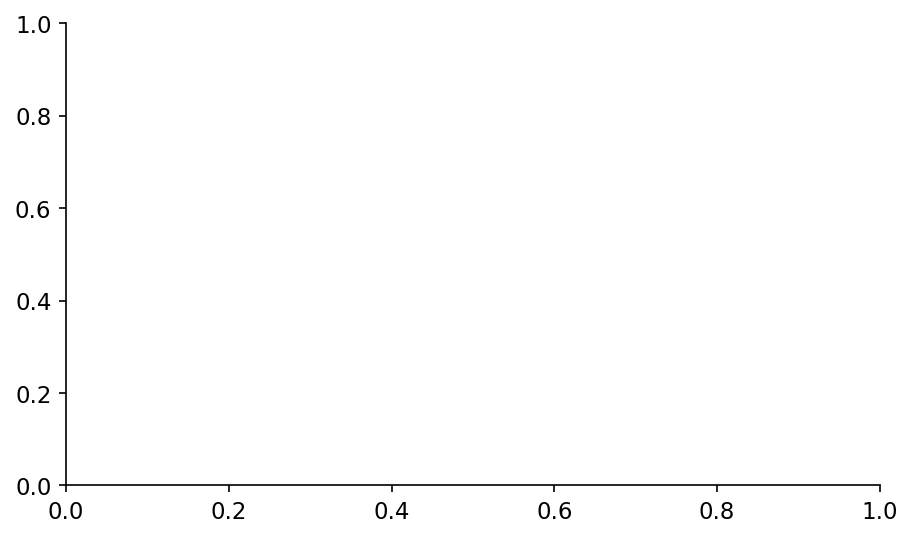

In [28]:
print("\n── STEP 7: generating plots ──")

if "timer_dist" in core_metrics:
    plot_timer_distribution(core_metrics["timer_dist"], FIG_DIR)

if "summary" in core_metrics:
    plot_assignment_funnel(core_metrics["summary"], FIG_DIR)

if "assignment_latency" in core_metrics:
    plot_assignment_latency(core_metrics["assignment_latency"], FIG_DIR)

if "contention" in core_metrics:
    plot_slot_contention(core_metrics["contention"], FIG_DIR)

if "fairness" in core_metrics:
    plot_fairness(core_metrics["fairness"], FIG_DIR)

if "propagation" in core_metrics and not core_metrics["propagation"].empty:
    plot_propagation_latency(core_metrics["propagation"], FIG_DIR)

if "occupancy_timeline" in bridge_metrics:
    plot_occupancy_timeline(bridge_metrics["occupancy_timeline"], FIG_DIR)

if "slots_per_vehicle_gt" in bridge_metrics:
    plot_slots_per_vehicle(bridge_metrics["slots_per_vehicle_gt"], FIG_DIR)

if "spots_observed" in bridge_metrics:
    plot_spots_observed(bridge_metrics["spots_observed"], FIG_DIR)

if "sumo_summary" in van3_metrics:
    plot_vehicle_outcome(van3_metrics["sumo_summary"], FIG_DIR)

print(f"\n[plots] saved to {FIG_DIR}")

In [ ]:
print(f"\n{'='*60}")
print(f"  Done.")
print(f"{'='*60}\n")

In [ ]:
def process_single_experiment(exp_dir: Path, out_base: Path) -> dict | None:
    """Process one experiment directory. Returns summary dict or None."""
    exp_name = exp_dir.name
    out_dir = out_base / exp_name
    fig_dir = out_dir / "figures"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig_dir.mkdir(parents=True, exist_ok=True)

    runs = sorted([d for d in exp_dir.iterdir() if d.is_dir()])
    if not runs:
        print(f"  SKIP {exp_name}: no run directories")
        return None
    run_dir = runs[-1]

    sep = "=" * 60
    print(f"\n{sep}")
    print(f"  Processing: {exp_name}")
    print(f"  Run:        {run_dir.name}")
    print(f"{sep}")

    try:
        log_core   = _find_log(run_dir, "core",    "vanet-parking.log.*")
        log_bridge = _find_log(run_dir, "bridge",  "bridge.log.*")
        log_van3   = _find_log(run_dir, "van3twin","van3twin.log.*")
    except FileNotFoundError as e:
        print(f"  SKIP {exp_name}: {e}")
        return None

    df_core, _ = parse_core_log(log_core)
    df_bridge  = parse_bridge_log(log_bridge, None)
    df_van3    = parse_van3twin_log(log_van3)

    evts     = extract_core_events(df_core)
    core_m   = compute_core_metrics(evts, df_core)
    bridge_m = compute_bridge_metrics(df_bridge)
    van3_m   = compute_van3twin_metrics(df_van3)

    print("  --- CSVs ---")
    save_csvs(core_m, bridge_m, van3_m, out_dir)

    print("  --- Figures ---")
    for key, data, plot_fn in [
        ("timer_dist",         core_m,   plot_timer_distribution),
        ("summary",            core_m,   plot_assignment_funnel),
        ("assignment_latency", core_m,   plot_assignment_latency),
        ("contention",         core_m,   plot_slot_contention),
        ("fairness",           core_m,   plot_fairness),
        ("propagation",        core_m,   plot_propagation_latency),
        ("occupancy_timeline", bridge_m, plot_occupancy_timeline),
        ("slots_per_vehicle_gt", bridge_m, plot_slots_per_vehicle),
        ("spots_observed",     bridge_m, plot_spots_observed),
        ("sumo_summary",       van3_m,   plot_vehicle_outcome),
    ]:
        if key in data and isinstance(data[key], pd.DataFrame) and not data[key].empty:
            plot_fn(data[key], fig_dir)

    summary = {"experiment": exp_name}
    parts = exp_name.replace("combination_", "").split("_")
    summary["traffic"]    = parts[0]
    summary["occupancy"]  = int(parts[-1])

    if "summary" in core_m:
        s = core_m["summary"].iloc[0]
        for col in s.index:
            summary[f"A2_{col}"] = s[col]

    if "fairness" in core_m:
        summary["A5_jain"] = core_m["fairness"]["jain_index"].iloc[0]

    if "propagation" in core_m and not core_m["propagation"].empty:
        p = core_m["propagation"]["prop_latency_ms"]
        summary["A6_p50_ms"] = p.median()
        summary["A6_p95_ms"] = p.quantile(0.95)
        summary["A6_n"]      = len(p)

    if "contention" in core_m:
        c = core_m["contention"]
        summary["A4_mean"] = c["n_timers"].mean()
        summary["A4_max"]  = c["n_timers"].max()
        summary["A4_n_slots"] = len(c)

    if "assignment_latency" in core_m:
        el = core_m["assignment_latency"]["elapsed_ms"]
        summary["A3_p50_ms"] = el.median()
        summary["A3_p95_ms"] = el.quantile(0.95)

    if "sumo_summary" in van3_m:
        s = van3_m["sumo_summary"].iloc[0]
        summary["C1_entered"]   = int(s["vehicles_entered"])
        summary["C1_parked"]    = int(s["vehicles_parked"])
        summary["C1_park_rate"] = s["park_rate_pct"]

    if "timer_dist" in core_m:
        t = core_m["timer_dist"]["timer_ms"]
        summary["A1_p50_ms"] = t.median()
        summary["A1_mean_ms"] = t.mean()

    return summary

In [ ]:
print("\n" + "=" * 60)
print("  BATCH: Processing all experiments")
print("=" * 60 + "\n")

EXPERIMENTS = sorted([d for d in LOG_BASE.iterdir()
                       if d.is_dir() and d.name != "general_slurm"])
print(f"Found {len(EXPERIMENTS)} experiment directories\n")

all_summaries = []
for exp_dir in EXPERIMENTS:
    try:
        s = process_single_experiment(exp_dir, OUT_DIR)
        if s is not None:
            all_summaries.append(s)
    except Exception as e:
        print(f"  ERROR processing {exp_dir.name}: {e}")
        import traceback
        traceback.print_exc()

if all_summaries:
    df_summary = pd.DataFrame(all_summaries)
    summary_path = OUT_DIR / "summary_all_experiments.csv"
    df_summary.to_csv(summary_path, index=False)
    print(f"\n{'=' * 60}")
    print(f"  Aggregated {len(df_summary)} experiments -> {summary_path}")
    print(f"{'=' * 60}")
else:
    print("\n  No experiments processed successfully.")

In [ ]:
if not all_summaries:
    print("No data to aggregate.")
else:
    df_agg = pd.DataFrame(all_summaries)
    agg_dir = OUT_DIR / "aggregated"
    agg_dir.mkdir(exist_ok=True)
    fig_agg = agg_dir / "figures"
    fig_agg.mkdir(exist_ok=True)

    print(f"\n{'=' * 60}")
    print("  AGGREGATED SUMMARY (pivot tables by traffic x occupancy)")
    print(f"{'=' * 60}")

    metric_defs = [
        ("A2_success_rate_pct", "Success rate (%)"),
        ("A5_jain", "Jain fairness index"),
        ("A4_mean", "Mean contention (vehicles/slot)"),
        ("A3_p50_ms", "Assignment latency p50 (ms)"),
        ("A3_p95_ms", "Assignment latency p95 (ms)"),
        ("A6_p50_ms", "Propagation latency p50 (ms)"),
        ("A6_p95_ms", "Propagation latency p95 (ms)"),
        ("C1_park_rate", "Park rate (%)"),
    ]
    for metric, label in metric_defs:
        if metric not in df_agg.columns:
            continue
        try:
            pivot = df_agg.pivot_table(
                index="traffic", columns="occupancy",
                values=metric, aggfunc="first"
            )
            pivot.index.name = None
            print(f"\n  {label} [{metric}]")
            print(pivot.to_string(float_format=lambda x: f"{x:.2f}"))
            pivot.to_csv(agg_dir / f"{metric}_pivot.csv")
        except Exception as e:
            print(f"  Skipping {metric}: {e}")

    for metric, title, ylabel in [
        ("A2_success_rate_pct", "Success rate by traffic and occupancy",
         "Success rate (%)"),
        ("A5_jain", "Jain fairness index by traffic and occupancy",
         "Jain index"),
        ("A4_mean", "Mean slot contention by traffic and occupancy",
         "Mean vehicles/slot"),
        ("A3_p50_ms", "Median assignment latency by traffic and occupancy",
         "Latency p50 (ms)"),
        ("C1_park_rate", "Park rate by traffic and occupancy",
         "Park rate (%)"),
    ]:
        if metric not in df_agg.columns:
            continue
        fig, ax = plt.subplots(figsize=(10, 5))
        for traffic in sorted(df_agg["traffic"].unique()):
            subset = df_agg[df_agg["traffic"] == traffic].sort_values("occupancy")
            ax.plot(subset["occupancy"].astype(str), subset[metric],
                    marker="o", label=traffic)
        ax.set_xlabel("Parking occupancy (%)")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()
        fig.tight_layout()
        fig.savefig(fig_agg / f"{metric}_comparison.png")
        plt.close(fig)
        print(f"  [fig] {metric}_comparison.png")

    print(f"\n{'=' * 60}")
    print("  Aggregation complete.")
    print(f"{'=' * 60}\n")